# Finding Help: A Data Science Analysis of Online Help-Seeking Patterns for Domestic Violence Resources

## Objective

This notebook collects publicly available Google Trends data related to domestic violence support resources. I'll use this data throughout the project to explore patterns in online help-seeking behavior across the United States.

## Research Question

How have online search patterns for domestic violence support resources changed over time, and what insights can public search data provide about help-seeking behavior and resource awareness?

In [ ]:
# importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
from pytrends.request import TrendReq

Matplotlib is building the font cache; this may take a moment.
/Users/shraddha/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# connect to google trends

pytrends = TrendReq(
    hl="en-US",
    tz=360
)

print("Connected successfully!")

Connected successfully!


In [4]:
# search terms for the project

keywords = [
    "domestic violence help",
    "abuse hotline",
    "women's shelter",
    "emotional abuse",
    "teen dating violence"
]

# request for google trends data

pytrends.build_payload(
    keywords,
    timeframe="2019-01-01 2025-12-31",
    geo="US"
)

# store the results in a dataframe

trends = pytrends.interest_over_time()

# display the first few rows

trends.head()

,domestic violence help,abuse hotline,women's shelter,emotional abuse,teen dating violence,isPartial
date,,,,,,
2019-01-01,11,46,95,82,6,False
2019-02-01,10,38,79,84,13,False
2019-03-01,10,39,82,90,4,False
2019-04-01,12,42,81,85,4,False
2019-05-01,12,41,83,83,4,False


In [5]:
# saving the data to a csv file

trends.to_csv("../data/raw/google_trends.csv")
print("Data saved successfully!")

Data saved successfully!


In [6]:
# view basic information about the dataset

print("Dataset Shape:", trends.shape)

print("\nColumn Names:")
print(trends.columns)

print("\nMissing Values:")
print(trends.isnull().sum())

Dataset Shape: (84, 6)

Column Names:
Index(['domestic violence help', 'abuse hotline', 'women's shelter',
       'emotional abuse', 'teen dating violence', 'isPartial'],
      dtype='object')

Missing Values:
domestic violence help    0
abuse hotline             0
women's shelter           0
emotional abuse           0
teen dating violence      0
isPartial                 0
dtype: int64


In [7]:
# summary statistics

trends.describe()

,domestic violence help,abuse hotline,women's shelter,emotional abuse,teen dating violence
count,84.000000,84.000000,84.000000,84.000000,84.000000
mean,13.083333,35.345238,73.095238,80.297619,3.809524
std,2.537470,3.035906,10.153780,6.335556,2.752769
min,8.000000,29.000000,53.000000,68.000000,1.000000
25%,11.000000,33.000000,66.000000,75.750000,2.000000
50%,13.000000,36.000000,73.000000,80.000000,3.000000
75%,15.000000,37.000000,81.250000,84.000000,4.000000
max,21.000000,46.000000,100.000000,96.000000,13.000000


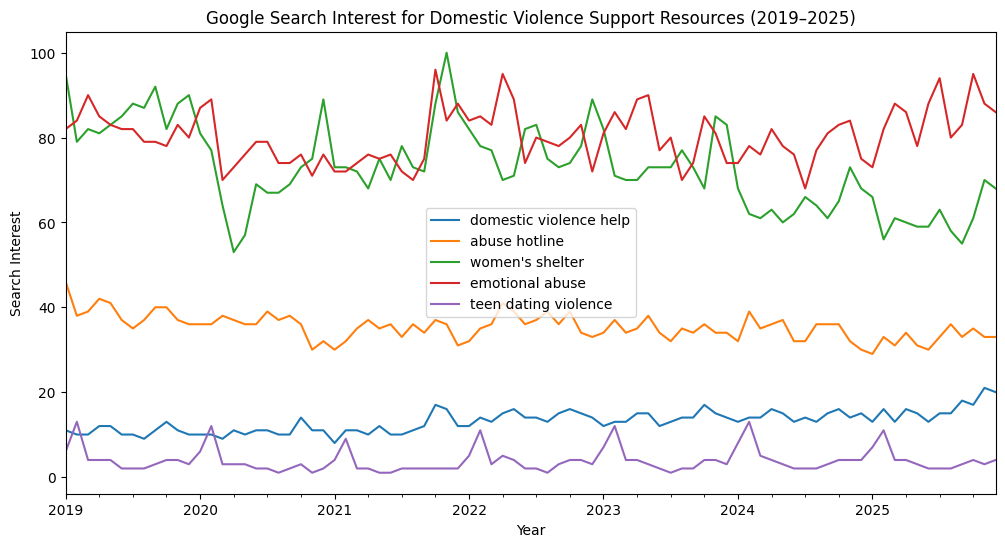

In [8]:
# plotting search interest over time

trends.drop(columns="isPartial").plot(figsize=(12, 6))

plt.title("Google Search Interest for Domestic Violence Support Resources (2019–2025)")
plt.xlabel("Year")
plt.ylabel("Search Interest")

plt.show()

## Initial Observations

- Looking at the data, it's clear that some search terms are much more common than others.
- The search interest also changes over time instead of staying the same each month, which makes me wonder what might be causing those changes.
- Even though Google Trends can't tell us how many people are experiencing domestic violence, it can show how people are searching for information and support.
- As I continue this project, I want to see if there are any noticeable patterns and think about how this kind of data could help organizations better understand when people may be looking for resources.